In [1]:
from utils.binaries import *
from utils.plotting import *

# Data gathered from CORSIKA 8 apptainer with /opt/corsika8/install/bin/c8_air_shower binary
# c8_air_shower -E 100000 -p 1000260560 -M SIBYLL-2.3d -N 1 -f 1e17_sibyll_iron

09:22:40 (  +76.3s) [INFO   ] -- import logging
09:22:40 (  +225ms) [INFO   ] -- import numpy as np
09:22:40 (    +5ms) [INFO   ] -- import uncertainties
09:22:42 (   +1.2s) [INFO   ] -- import pandas as pd
09:22:42 (    +1ms) [WARNING] -- pandas support to be dropped at some point!
09:22:42 (    +1ms) [INFO   ] -- import binaries.tools as tools
09:22:42 (    +1ms) [INFO   ] -- set MONI_PATH = PosixPath('/home/filip/Data/monit_and_sd')
09:22:42 (    +0ms) [INFO   ] -- set HIST_PATH = PosixPath('/home/filip/Data/monit_and_sd')
09:22:42 (    +0ms) [INFO   ] -- set PLOT_PATH = PosixPath('/home/filip/Data/plots')
09:22:42 (    +1ms) [INFO   ] -- set DATA_PATH = PosixPath('/home/filip/Data')
09:22:42 (    +0ms) [INFO   ] -- set SCAN_PATH = PosixPath('/home/filip/Public/xy-calibration')
09:22:42 (    +0ms) [INFO   ] -- set OFLN_PATH = PosixPath('/home/filip/Public/offline/install')
09:22:42 (  +361ms) [INFO   ] -- import matplotlib.pyplot as plt
09:22:43 (  +611ms) [INFO   ] -- import seabor

09:23:34 (  +32.4s) [DEBUG  ] -- font size set to 9.5
09:23:34 (    +2ms) [DEBUG  ] -- label size set to 13.0
09:23:34 (    +0ms) [DEBUG  ] -- figure size set to [2.2, 2.5]
09:23:34 (    +0ms) [DEBUG  ] -- markersize set to 2.0
09:23:34 (    +1ms) [DEBUG  ] -- usetex set to False


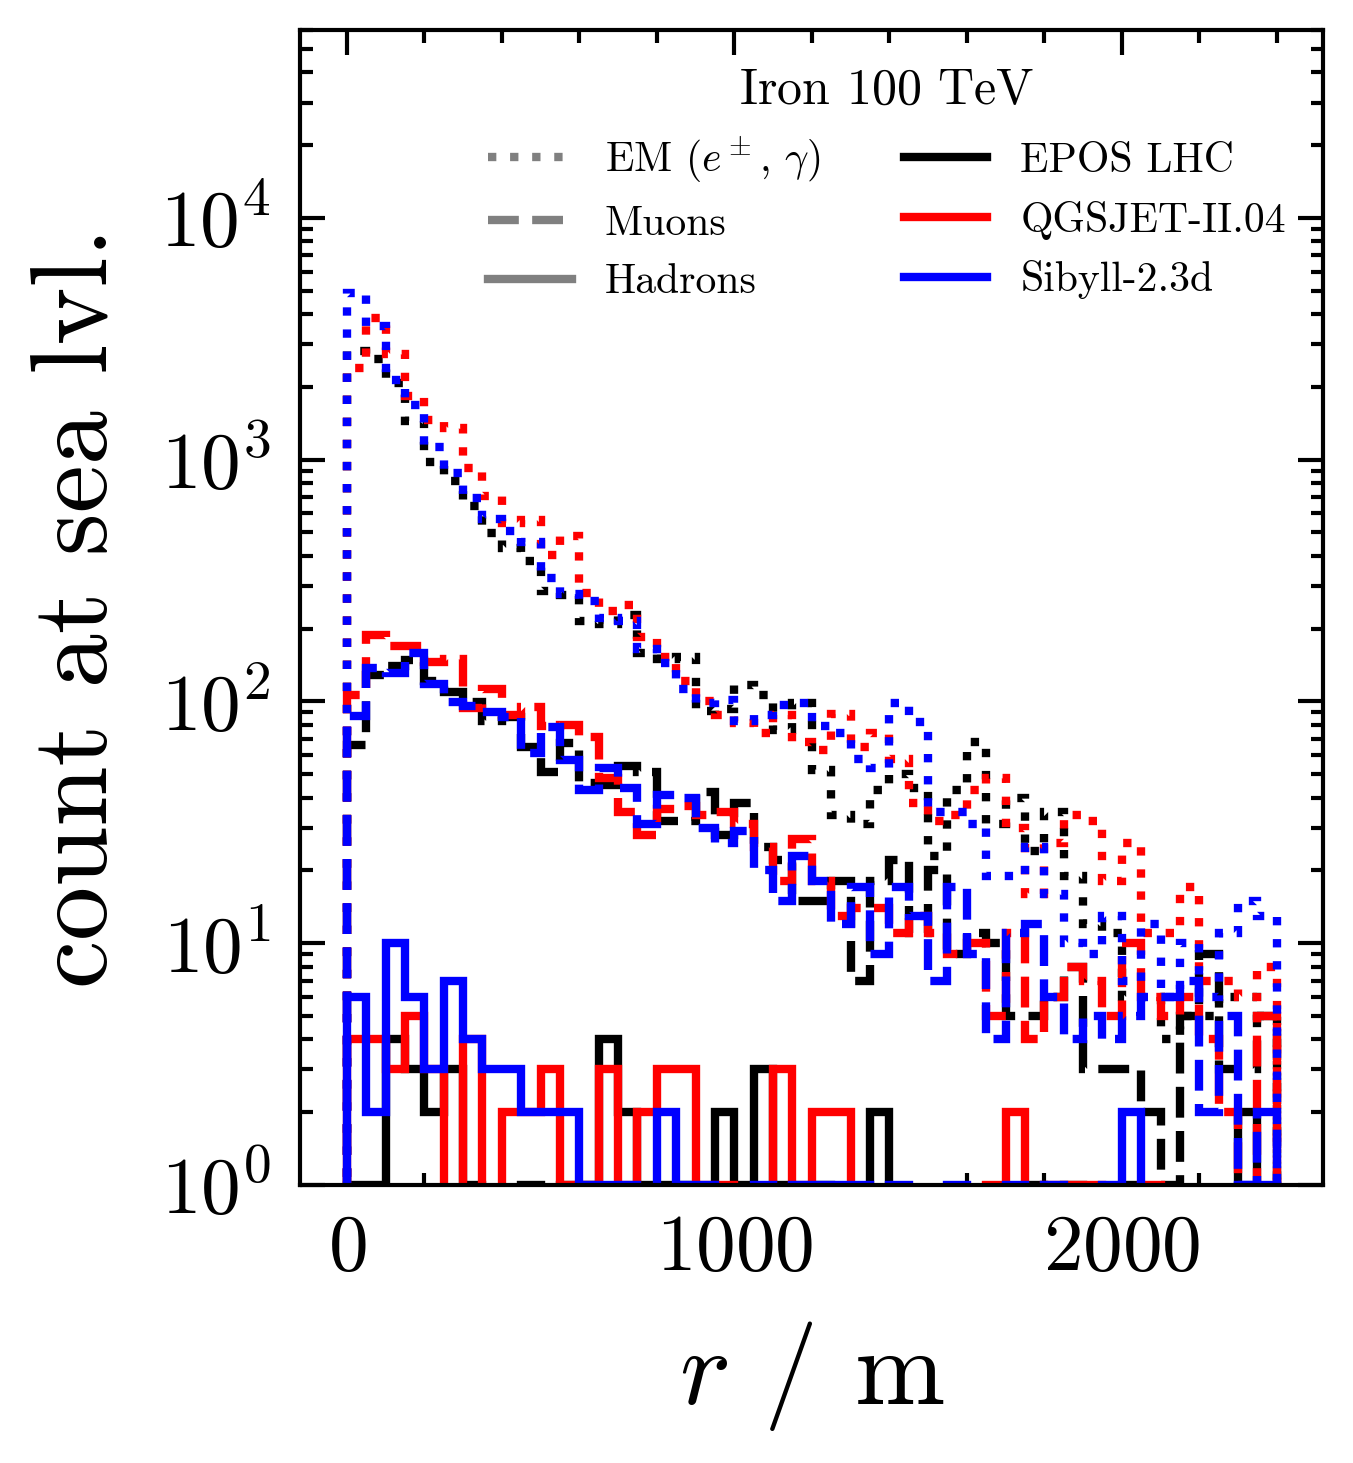

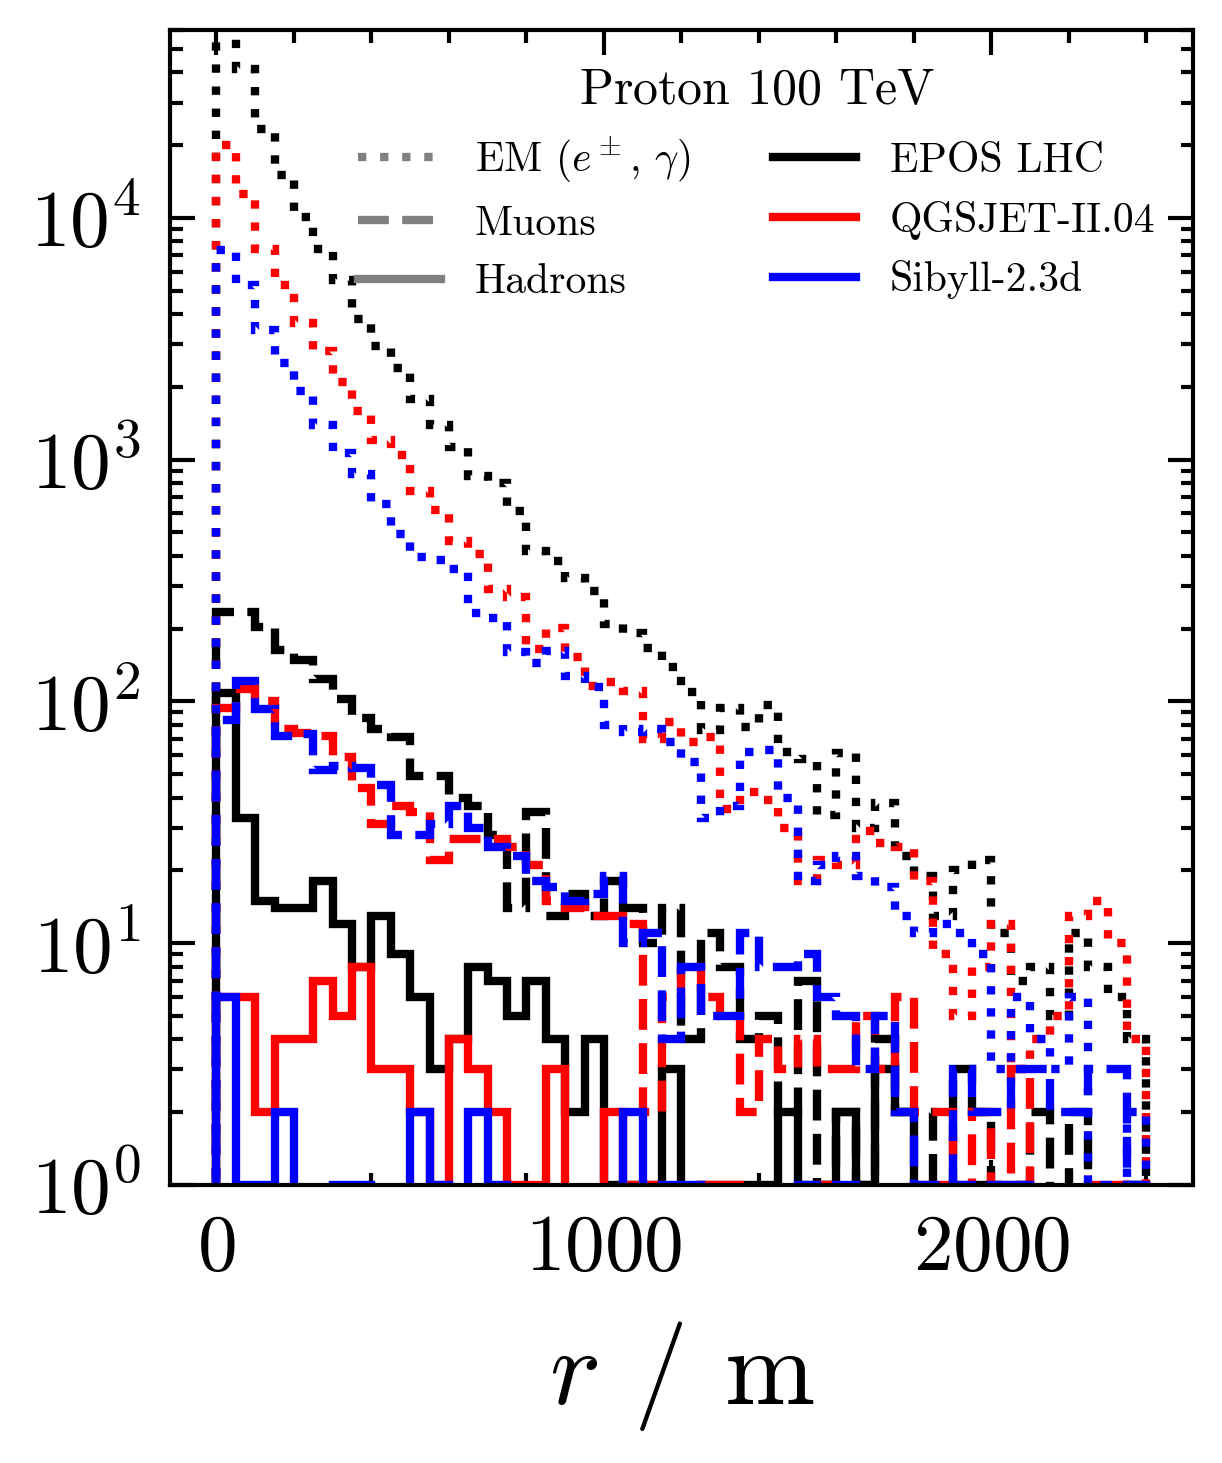

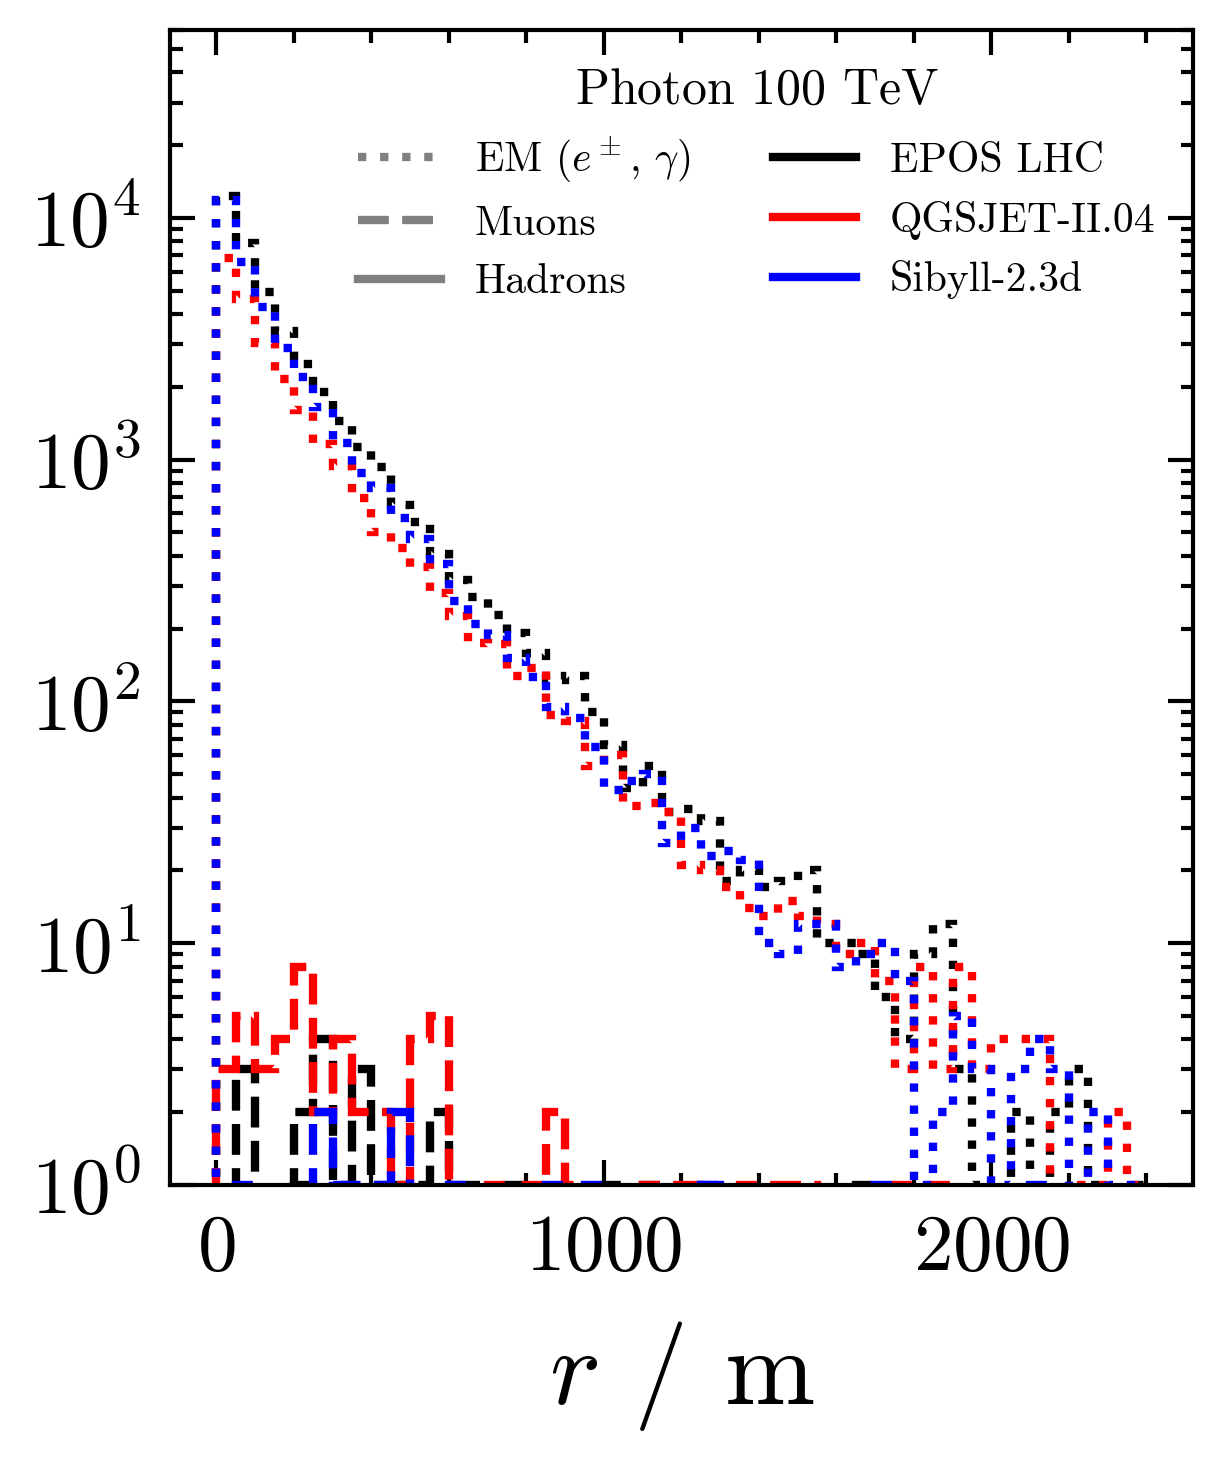

In [4]:
set_plt_style("triple")

select_em = lambda df: df[(df["pdg"] == 22) | (df["pdg"] == 11) | (df["pdg"] == -11)]
select_mu = lambda df: df[(df["pdg"] == 13) | (df["pdg"] == -13)]
select_hd = lambda df: df[(df["pdg"] != 22) & (df["pdg"].abs() != 13) & (df["pdg"].abs() != 11)]
r = lambda df: np.sqrt(df['x'].values**2 + df['y'].values**2)

c = {
    'epos_lhc': "k",
    'qgsjet': "r",
    'sibyll': "b"
}

for primary in ['photon', 'proton', 'iron'][::-1]:
    plt.figure()
    for model in ["epos_lhc", 'qgsjet', 'sibyll']:

        try:
            data = pd.read_parquet(f"/home/filip/Public/CORSIKA8/1e17_{model}_{primary}/particles/particles.parquet")

            data_em = select_em(data)
            data_mu = select_mu(data)
            data_hd = select_hd(data)
        
            plt.hist(r(data_em), color=c[model], linestyle=':', 
                     histtype='step', bins=48, range=(0, 2400), lw=0.1)

            plt.hist(r(data_mu), color=c[model], linestyle='--', 
                     histtype='step', bins=48, range=(0, 2400), lw=0.1)
            
            plt.hist(r(data_hd), color=c[model], linestyle='-',
                     histtype='step', bins=48, range=(0, 2400), lw=0.1)

        except Exception as e:
            print(primary, model, e)
            continue
    
    # leg1 = plt.gca().legend(handles=[em, hd], title=f"{primary.capitalize()} $100$ TeV",
    #                         ncol=2, title_fontsize=6, fontsize=4.5, loc='upper left')
    # plt.gca().add_artist(leg1)

    em = plt.errorbar([], [], c='gray', ls=':', label="EM ($e^\pm$, $\gamma$)", marker='none')
    hd = plt.errorbar([], [], c='gray', ls='--', label="Muons", marker='none')
    hd = plt.errorbar([], [], c='gray', ls='-', label="Hadrons", marker='none')
    epos = plt.errorbar([], [], ls='-', label="EPOS LHC", marker='none')
    qgs = plt.errorbar([], [], ls='-', label="QGSJET-II.04", marker='none')
    sibyll = plt.errorbar([], [], ls='-', label="Sibyll-2.3d", marker='none')
    # leg2 = plt.gca().legend(handles=[epos, qgs, sibyll], fontsize=3.6, loc='upper right')
    # plt.gca().add_artist(leg2)
    plt.legend(title=f"{primary.capitalize()} $100$ TeV",
               ncol=2, title_fontsize=6, fontsize=5, loc='upper right')

    plt.xlabel("$r$ / m")
    plt.ylabel("count at sea lvl." if primary=='iron' else '')
    plt.yscale("log")
    plt.yscale("log")
    plt.ylim(1, 6e4)

    plot.save(plt.gcf(), f"eas-showers/{primary}")

    # break

In [8]:
data = pd.read_parquet(f"/home/filip/Public/CORSIKA8/1e17_epos_lhc_proton/particles/particles.parquet")
data

,shower,pdg,kinetic_energy,x,y,nx,ny,nz,time,weight
0,0,22,0.056160,-405.128510,318.409882,-0.080877,0.253790,-0.963872,0.000376,1.0
1,0,-13,4.003055,-406.157715,204.188568,-0.070573,0.021006,-0.997285,0.000376,1.0
2,0,22,0.013905,318.174835,-117.297180,0.241331,-0.032007,-0.969915,0.000376,1.0
3,0,22,0.271509,262.567535,-112.289619,0.061559,-0.031505,-0.997606,0.000376,1.0
4,0,22,0.000512,269.843597,-181.674332,0.085467,-0.287298,-0.954021,0.000376,1.0
...,...,...,...,...,...,...,...,...,...,...
203543,0,22,0.004081,320.826996,-13.514359,0.129738,-0.413612,-0.901162,0.000376,1.0
203544,0,22,0.001470,-259.426697,-449.607147,-0.230813,-0.847802,-0.477448,0.000377,1.0
203545,0,11,0.014671,-8.651050,140.958145,0.306577,-0.426395,-0.850998,0.000376,1.0
203546,0,13,98.146782,-13.105893,145.376038,-0.001044,0.014908,-0.999888,0.000376,1.0
